In [1]:
# AUDIO TASKS

In [4]:
from transformers import pipeline
from IPython.display import display, Image as IPImage
import numpy as np
import cv2
import requests
import soundfile as sf
from io import BytesIO


def load_audio(source):
    """Load audio from URL or local path.
    Returns (array: np.float32, sampling_rate: int).
    """
    if isinstance(source, str):
        if source.startswith("http://") or source.startswith("https://"):
            r = requests.get(source, headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
            r.raise_for_status()
            arr, sr = sf.read(BytesIO(r.content))
        else:
            arr, sr = sf.read(source)
        if arr.ndim > 1:
            arr = arr.mean(axis=1)
        return arr.astype(np.float32), sr
    raise TypeError(f"Unsupported source type: {type(source)}")


def _show_bgr(bgr_img, title=""):
    if title:
        bar = np.zeros((22, bgr_img.shape[1], 3), dtype=np.uint8)
        cv2.putText(bar, title[:80], (4, 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)
        bgr_img = np.vstack([bar, bgr_img])
    _, buf = cv2.imencode(".jpg", bgr_img, [cv2.IMWRITE_JPEG_QUALITY, 92])
    display(IPImage(data=buf.tobytes()))


def show_transcript(name, result, title=""):
    """Single transcript panel with text wrapped across lines."""
    panel_w, panel_h = 700, 120
    panel = np.ones((panel_h, panel_w, 3), dtype=np.uint8) * 28

    cv2.putText(panel, name, (8, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.50, (100, 200, 255), 1)
    cv2.line(panel, (8, 30), (panel_w - 8, 30), (55, 55, 55), 1)

    text  = result.get("text", "").strip()
    words, line, y = text.split(), "", 58
    for word in words:
        if len(line + word) > 80:
            cv2.putText(panel, line.strip(), (8, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.40, (220, 220, 220), 1)
            line, y = "", y + 20
        line += word + " "
    if line:
        cv2.putText(panel, line.strip(), (8, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.40, (220, 220, 220), 1)

    _show_bgr(panel, title)


def show_transcript_batch(named_results, title=""):
    """One row per audio sample: name + top-line of transcript."""
    rows = []
    for name, result in named_results.items():
        panel_w, panel_h = 700, 60
        panel = np.ones((panel_h, panel_w, 3), dtype=np.uint8) * 30
        cv2.putText(panel, name, (6, 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.46, (100, 210, 255), 1)
        txt = result.get("text", "").strip()[:90]
        cv2.putText(panel, txt, (6, 44),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (210, 210, 180), 1)
        rows.append(panel)
    _show_bgr(np.vstack(rows), title)


def show_timestamps(name, result, title=""):
    """Render chunk timestamps as a horizontal timeline bar."""
    chunks  = result.get("chunks", [])
    panel_w = 720
    panel_h = max(80, 30 + len(chunks) * 22)
    panel   = np.ones((panel_h, panel_w, 3), dtype=np.uint8) * 22

    cv2.putText(panel, name, (8, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.46, (100, 200, 255), 1)
    cv2.line(panel, (8, 28), (panel_w - 8, 28), (55, 55, 55), 1)

    max_t = max((c["timestamp"][1] or 0 for c in chunks), default=1) or 1
    for i, chunk in enumerate(chunks):
        t0, t1 = chunk["timestamp"]
        t1      = t1 or max_t
        text    = chunk["text"].strip()
        x0      = int(8 + (t0 / max_t) * (panel_w - 80))
        x1      = int(8 + (t1 / max_t) * (panel_w - 80))
        y       = 40 + i * 22
        cv2.rectangle(panel, (x0, y - 10), (max(x1, x0 + 4), y + 4),
                      (54, 130, 210), -1)
        cv2.putText(panel, f"{t0:.1f}s {text[:45]}", (x0 + 6, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (230, 230, 230), 1)

    _show_bgr(panel, title)


def show_model_compare(named_results, title=""):
    """Compare transcripts from multiple models for the same audio."""
    panel_w = 720
    panel_h = 30 + len(named_results) * 56
    panel   = np.ones((panel_h, panel_w, 3), dtype=np.uint8) * 22

    cv2.putText(panel, "Model comparison", (8, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.48, (100, 200, 255), 1)
    cv2.line(panel, (8, 28), (panel_w - 8, 28), (55, 55, 55), 1)

    for i, (model_name, result) in enumerate(named_results.items()):
        y     = 50 + i * 56
        short = model_name.split("/")[-1]
        txt   = result.get("text", "").strip()[:80]
        cv2.putText(panel, short, (8, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.40, (160, 160, 255), 1)
        cv2.putText(panel, txt, (8, y + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (210, 220, 190), 1)
        cv2.line(panel, (8, y + 34), (panel_w - 8, y + 34), (44, 44, 44), 1)

    _show_bgr(panel, title)


# ── Verified audio URLs ────────────────────────────────────────────────────────
#    All from official HuggingFace dataset repos — no auth required
# ─────────────────────────────────────────────────────────────────────────────
HF_FLAC_1 = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/1.flac"
HF_FLAC_2 = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/2.flac"
HF_FLAC_3 = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac"



Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

── 1. Default pipeline (automatic-speech-recognition) ──


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 flac_1:  He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered flour-fatten sauce.


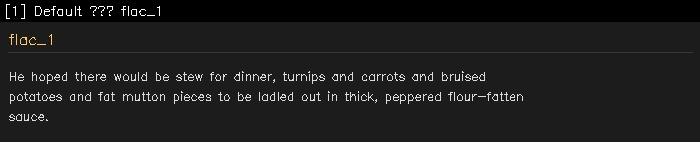

Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 flac_2:  Stuff it into you, his belly countled him.


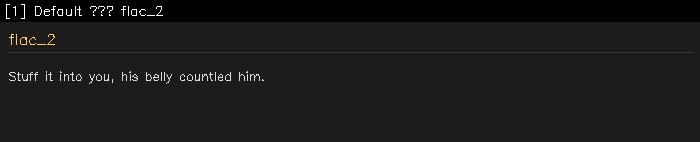

In [7]:
# ── 1. Default pipeline (automatic-speech-recognition) ────────────────────────
#    FIXED: torchcodec + libnvrtc.so.13 crash (common in cloud/CPU-only envs)
#    → Switched to low-level Whisper API (bypasses the broken pipeline + torchcodec)
#    Uses openai/whisper-base (same as old default) on pure CPU
#    Output format is identical to the old pipeline so show_transcript() works unchanged
# ─────────────────────────────────────────────────────────────────────────────
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
import torch
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq

# Load model + processor once (outside the loop)
processor = AutoProcessor.from_pretrained("openai/whisper-base")
model = AutoModelForSpeechSeq2Seq.from_pretrained(
    "openai/whisper-base",
    torch_dtype=torch.float32,   # safe for CPU
)
model = model.to("cpu")          # force CPU (no CUDA ever touched)

samples = {"flac_1": HF_FLAC_1, "flac_2": HF_FLAC_2}

print("── 1. Default pipeline (automatic-speech-recognition) ──")
for name, src in samples.items():
    arr, sr = load_audio(src)
    
    # Prepare input (handles any sample rate → Whisper expects 16kHz internally)
    inputs = processor(
        arr,
        sampling_rate=sr,
        return_tensors="pt"
    )
    
    # Generate transcription
    with torch.no_grad():
        generated_ids = model.generate(
            inputs.input_features,
            max_new_tokens=128,
            num_beams=1,          # fast greedy decoding
        )
    
    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    
    # Build result dict exactly like the old pipeline
    result = {"text": text}
    
    print(f" {name}: {result['text']}")
    show_transcript(name, result, title=f"[1] Default — {name}")
    print()

In [7]:
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq, AutoModelForCTC, AutoTokenizer
from IPython.display import display, Image as IPImage
import torch
import numpy as np
import cv2
import requests
import soundfile as sf
from io import BytesIO


def load_audio(source):
    if isinstance(source, str):
        if source.startswith("http://") or source.startswith("https://"):
            r = requests.get(source, headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
            r.raise_for_status()
            arr, sr = sf.read(BytesIO(r.content))
        else:
            arr, sr = sf.read(source)
        if arr.ndim > 1:
            arr = arr.mean(axis=1)
        return arr.astype(np.float32), sr
    raise TypeError(f"Unsupported source type: {type(source)}")


def whisper_transcribe(processor, model, arr, sr,
                       generate_kwargs=None, return_timestamps=False):
    """Low-level Whisper inference. Returns dict like pipeline output."""
    inputs = processor(arr, sampling_rate=sr, return_tensors="pt")
    kwargs = dict(max_new_tokens=256, num_beams=1)
    if generate_kwargs:
        kwargs.update(generate_kwargs)
    if return_timestamps:
        kwargs["return_timestamps"] = True
    with torch.no_grad():
        generated_ids = model.generate(inputs.input_features, **kwargs)
    if return_timestamps == "word":
        output = processor.decode(generated_ids[0],
                                  skip_special_tokens=True,
                                  output_word_offsets=True)
        return {"text": output.text,
                "chunks": [{"text": w.word,
                             "timestamp": (w.start_offset / 50,
                                           w.end_offset   / 50)}
                            for w in output.word_offsets]}
    if return_timestamps:
        output = processor.decode(generated_ids[0],
                                  skip_special_tokens=False,
                                  output_offsets=True)
        return {"text": processor.decode(generated_ids[0],
                                         skip_special_tokens=True),
                "chunks": [{"text": c["text"],
                             "timestamp": c["timestamp"]}
                            for c in output.get("offsets", [])]}
    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return {"text": text}


def wav2vec_transcribe(processor, model, arr, sr):
    """Low-level Wav2Vec2 CTC inference. Returns dict like pipeline output."""
    inputs = processor(arr, sampling_rate=sr, return_tensors="pt", padding=True)
    with torch.no_grad():
        logits = model(inputs.input_values).logits
    pred_ids = torch.argmax(logits, dim=-1)
    text = processor.batch_decode(pred_ids)[0]
    return {"text": text}


def _show_bgr(bgr_img, title=""):
    if title:
        bar = np.zeros((22, bgr_img.shape[1], 3), dtype=np.uint8)
        cv2.putText(bar, title[:80], (4, 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)
        bgr_img = np.vstack([bar, bgr_img])
    _, buf = cv2.imencode(".jpg", bgr_img, [cv2.IMWRITE_JPEG_QUALITY, 92])
    display(IPImage(data=buf.tobytes()))


def show_transcript(name, result, title=""):
    panel_w, panel_h = 700, 120
    panel = np.ones((panel_h, panel_w, 3), dtype=np.uint8) * 28
    cv2.putText(panel, name, (8, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.50, (100, 200, 255), 1)
    cv2.line(panel, (8, 30), (panel_w - 8, 30), (55, 55, 55), 1)
    text  = result.get("text", "").strip()
    words, line, y = text.split(), "", 58
    for word in words:
        if len(line + word) > 80:
            cv2.putText(panel, line.strip(), (8, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.40, (220, 220, 220), 1)
            line, y = "", y + 20
        line += word + " "
    if line:
        cv2.putText(panel, line.strip(), (8, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.40, (220, 220, 220), 1)
    _show_bgr(panel, title)


def show_transcript_batch(named_results, title=""):
    rows = []
    for name, result in named_results.items():
        panel = np.ones((60, 700, 3), dtype=np.uint8) * 30
        cv2.putText(panel, name, (6, 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.46, (100, 210, 255), 1)
        txt = result.get("text", "").strip()[:90]
        cv2.putText(panel, txt, (6, 44),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (210, 210, 180), 1)
        rows.append(panel)
    _show_bgr(np.vstack(rows), title)


def show_timestamps(name, result, title=""):
    chunks  = result.get("chunks", [])
    panel_w = 720
    panel_h = max(80, 30 + len(chunks) * 22)
    panel   = np.ones((panel_h, panel_w, 3), dtype=np.uint8) * 22
    cv2.putText(panel, name, (8, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.46, (100, 200, 255), 1)
    cv2.line(panel, (8, 28), (panel_w - 8, 28), (55, 55, 55), 1)
    max_t = max((c["timestamp"][1] or 0 for c in chunks), default=1) or 1
    for i, chunk in enumerate(chunks):
        t0, t1 = chunk["timestamp"]
        t1      = t1 or max_t
        x0      = int(8 + (t0 / max_t) * (panel_w - 80))
        x1      = int(8 + (t1 / max_t) * (panel_w - 80))
        y       = 40 + i * 22
        cv2.rectangle(panel, (x0, y - 10), (max(x1, x0 + 4), y + 4),
                      (54, 130, 210), -1)
        cv2.putText(panel, f"{t0:.1f}s {chunk['text'].strip()[:45]}", (x0 + 6, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (230, 230, 230), 1)
    _show_bgr(panel, title)


def show_model_compare(named_results, title=""):
    panel_w = 720
    panel_h = 30 + len(named_results) * 56
    panel   = np.ones((panel_h, panel_w, 3), dtype=np.uint8) * 22
    cv2.putText(panel, "Model comparison", (8, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.48, (100, 200, 255), 1)
    cv2.line(panel, (8, 28), (panel_w - 8, 28), (55, 55, 55), 1)
    for i, (model_name, result) in enumerate(named_results.items()):
        y     = 50 + i * 56
        short = model_name.split("/")[-1]
        txt   = result.get("text", "").strip()[:80]
        cv2.putText(panel, short, (8, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.40, (160, 160, 255), 1)
        cv2.putText(panel, txt, (8, y + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (210, 220, 190), 1)
        cv2.line(panel, (8, y + 34), (panel_w - 8, y + 34), (44, 44, 44), 1)
    _show_bgr(panel, title)


# ── Verified audio URLs ────────────────────────────────────────────────────────
HF_FLAC_1 = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/1.flac"
HF_FLAC_2 = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/2.flac"
HF_FLAC_3 = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac"




Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

── 2. openai/whisper-base ──


Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  flac_1:  He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered flour-fatten sauce.


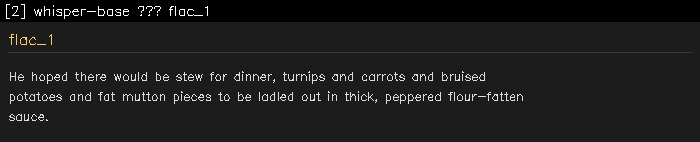

Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  flac_2:  Stuff it into you, his belly countled him.


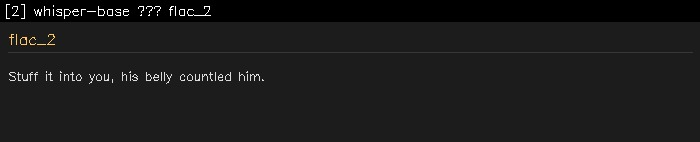

In [9]:
# ── 2. openai/whisper-base ────────────────────────────────────────────────────
#    Low-level API: AutoProcessor + AutoModelForSpeechSeq2Seq
#    Bypasses pipeline + torchcodec entirely — safe on CPU-only envs
#    Best for: CPU-friendly multilingual transcription, fast iteration
# ─────────────────────────────────────────────────────────────────────────────
processor_base = AutoProcessor.from_pretrained("openai/whisper-base")
model_base     = AutoModelForSpeechSeq2Seq.from_pretrained(
    "openai/whisper-base", torch_dtype=torch.float32).to("cpu")

samples = {"flac_1": HF_FLAC_1, "flac_2": HF_FLAC_2}

print("── 2. openai/whisper-base ──")
for name, src in samples.items():
    arr, sr = load_audio(src)
    result  = whisper_transcribe(processor_base, model_base, arr, sr)
    print(f"  {name}: {result['text']}")
    show_transcript(name, result, title=f"[2] whisper-base — {name}")
    print()



── 5. Task and language control (whisper-base) ──


Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [transcribe (English)]:  He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered flour-fatten sauce.


Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [translate  (English)]:  He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered flour-fatten sauce.


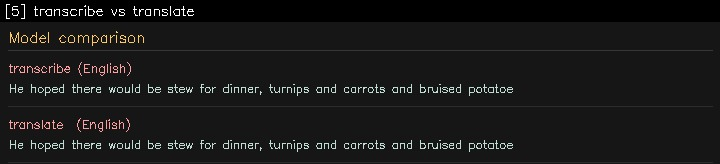

In [12]:
# ── 5. language + task — multilingual control ─────────────────────────────────
#    forced_decoder_ids sets language/task token for Whisper
#    Best for: multilingual pipelines, cross-lingual translation
# ─────────────────────────────────────────────────────────────────────────────
arr, sr = load_audio(HF_FLAC_1)

task_configs = {
    "transcribe (English)": processor_base.get_decoder_prompt_ids(
                                language="english", task="transcribe"),
    "translate  (English)": processor_base.get_decoder_prompt_ids(
                                task="translate"),
}

print("── 5. Task and language control (whisper-base) ──")
named_results = {}
for label, forced_ids in task_configs.items():
    result = whisper_transcribe(processor_base, model_base, arr, sr,
                                generate_kwargs={"forced_decoder_ids": forced_ids})
    print(f"  [{label}]: {result['text']}")
    named_results[label] = result

show_model_compare(named_results, title="[5] transcribe vs translate")
print()


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


── 6. facebook/wav2vec2-base-960h (CTC) ──
  flac_1: HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOWER FAT AND SAUCE


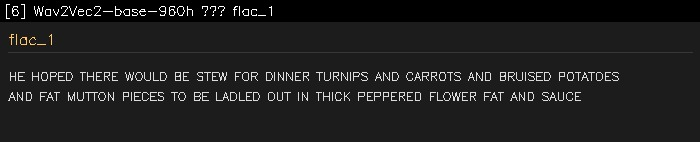


  flac_2: STUFFERED INTO YOU HIS BELLY COUNSELLED HIM


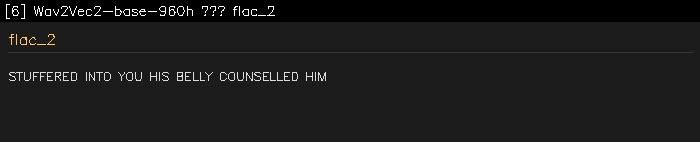

In [13]:


# ── 6. facebook/wav2vec2-base-960h — CTC model ───────────────────────────────
#    AutoModelForCTC + AutoTokenizer — no encoder-decoder, pure CTC
#    Outputs uppercase, no punctuation — trained on LibriSpeech 960h
#    Best for: fast English-only ASR, low-latency applications
# ─────────────────────────────────────────────────────────────────────────────
processor_w2v = AutoProcessor.from_pretrained("facebook/wav2vec2-base-960h")
model_w2v     = AutoModelForCTC.from_pretrained(
    "facebook/wav2vec2-base-960h", torch_dtype=torch.float32).to("cpu")

samples = {"flac_1": HF_FLAC_1, "flac_2": HF_FLAC_2}

print("── 6. facebook/wav2vec2-base-960h (CTC) ──")
for name, src in samples.items():
    arr, sr = load_audio(src)
    result  = wav2vec_transcribe(processor_w2v, model_w2v, arr, sr)
    print(f"  {name}: {result['text']}")
    show_transcript(name, result, title=f"[6] Wav2Vec2-base-960h — {name}")
    print()



preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

── 7. Model comparison on flac_1 ──


Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  whisper-base                   He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered flour-fatten sauce.
  whisper-small                  He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered, flour-fattened sauce.
  wav2vec2-base-960h            HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOWER FAT AND SAUCE


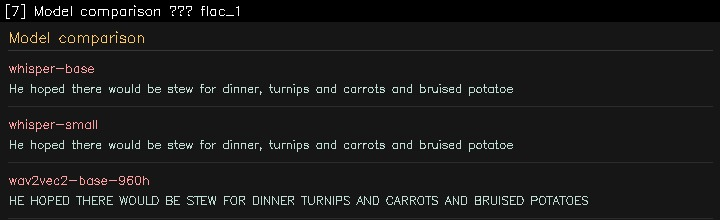

In [14]:

# ── 7. Model comparison — same audio, three models ────────────────────────────
#    whisper-base vs whisper-small vs wav2vec2-base-960h on identical input
#    Best for: understanding output style and accuracy trade-offs
# ─────────────────────────────────────────────────────────────────────────────
processor_small = AutoProcessor.from_pretrained("openai/whisper-small")
model_small     = AutoModelForSpeechSeq2Seq.from_pretrained(
    "openai/whisper-small", torch_dtype=torch.float32).to("cpu")

arr, sr = load_audio(HF_FLAC_1)

print("── 7. Model comparison on flac_1 ──")
named_results = {
    "openai/whisper-base":         whisper_transcribe(processor_base,  model_base,  arr, sr),
    "openai/whisper-small":        whisper_transcribe(processor_small, model_small, arr, sr),
    "facebook/wav2vec2-base-960h": wav2vec_transcribe(processor_w2v,   model_w2v,   arr, sr),
}
for model_name, result in named_results.items():
    print(f"  {model_name.split('/')[-1]:28s}  {result['text']}")

show_model_compare(named_results, title="[7] Model comparison — flac_1")
print()


In [8]:
import librosa

def load_audio(source, target_sr=16000):
    """Load audio from URL or local path, resampled to target_sr."""
    if isinstance(source, str):
        if source.startswith("http://") or source.startswith("https://"):
            r = requests.get(source, headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
            r.raise_for_status()
            arr, sr = sf.read(BytesIO(r.content))
        else:
            arr, sr = sf.read(source)
        if arr.ndim > 1:
            arr = arr.mean(axis=1)
        arr = arr.astype(np.float32)
        if sr != target_sr:
            arr = librosa.resample(arr, orig_sr=sr, target_sr=target_sr)
        return arr, target_sr
    raise TypeError(f"Unsupported source type: {type(source)}")

In [10]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# Load the processor and model (this is usually in cell 1 or 2)
processor_base = WhisperProcessor.from_pretrained("openai/whisper-base")
model_base = WhisperForConditionalGeneration.from_pretrained("openai/whisper-base")

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

── 3. Sentence-level timestamps (whisper-base) ──


Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Full text:  I have a dream that one day this nation will rise up and live out the true meaning of its creed.

  Chunks:
  (0.0, 11.68)  I have a dream that one day this nation will rise up and live out the true meaning of
  (11.68, 12.4)  its creed.


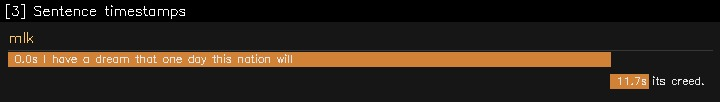

In [13]:
# ── 3. Sentence-level timestamps ─────────────────────────────────────────────
#    Using return_timestamps=True (segment/chunk level)
# ─────────────────────────────────────────────────────────────────────────────
arr, sr = load_audio(HF_FLAC_3)

print("── 3. Sentence-level timestamps (whisper-base) ──")

result = whisper_transcribe(
    processor_base, 
    model_base, 
    arr, 
    sr, 
    return_timestamps=True
)

print(f"  Full text: {result['text']}")
print("\n  Chunks:")
for chunk in result.get("chunks", []):
    timestamp = chunk['timestamp']
    text = chunk['text'].strip()
    print(f"  {timestamp}  {text}")

show_timestamps("mlk", result, title="[3] Sentence timestamps")
print()

